# Diabetes Prediction using Machine Learning
## Pima Indians Diabetes Dataset Analysis

**Author:** Mohammad Nakibul Ezaz  
**Dataset:** Pima Indians Diabetes Database  
**Objective:** Binary classification to predict diabetes presence

---

## Introduction

Diabetes mellitus is a chronic metabolic disorder affecting millions worldwide, with serious complications including cardiovascular disease, neuropathy, and kidney failure. Early detection and prediction of diabetes risk is crucial for clinical intervention and prevention programs. Machine learning has emerged as a powerful tool for disease prediction, offering faster and more accurate classification compared to traditional clinical methods.

Previous research has demonstrated that supervised learning algorithms, particularly ensemble methods, can achieve high accuracy in diabetes prediction when applied to structured medical datasets. Studies using the Pima Indians Diabetes Dataset have reported classification accuracies ranging from 75% to 82% with various machine learning models.

This work addresses the challenge of developing a robust, interpretable diabetes prediction model that balances high sensitivity (recall) with precision. The motivation is to create a clinical decision support system that can identify high-risk individuals with minimal false negatives, ensuring no potential patients are missed during screening. Our approach combines multiple machine learning techniques including hyperparameter tuning, class imbalance handling with SMOTE, and ensemble methods to maximize predictive performance.

The objectives of this research are: 
- (1) to develop and compare multiple classification models
- (2) to optimize hyperparameters using cross-validation
- (3) to address class imbalance in the dataset
- (4) to provide clinically interpretable results; and
- (5) to recommend the best model for deployment in a clinical setting.

Our main contributions include: applying SMOTE for balanced training, conducting extensive hyperparameter optimization with GridSearchCV, implementing ensemble voting and stacking methods, and providing SHAP-based model interpretability. We expect to achieve approximately 80% accuracy with 85%+ ROC-AUC, significantly improving upon baseline models.

The remainder of this work is organized as follows: Methodology section describes data preprocessing, feature engineering, and model selection procedures; Results section presents quantitative performance metrics and visualizations; Discussion interprets findings in clinical context; and Conclusion summarizes key insights and limitations.

---

## Setup & Environment Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import shap
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, 
    GridSearchCV, cross_val_predict
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, auc
)


%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

RANDOM_SEED = 251000861
np.random.seed(RANDOM_SEED)

print(f"Environment initialized. Random seed: {RANDOM_SEED}")

Environment initialized. Random seed: 251000861


## Dataset Overview

In [2]:
def section_header(title):
    """Print formatted section header"""
    print("\n" + "="*80)
    print(title.upper())
    print("="*80)

df = pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')

section_header("Dataset Information")
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")


DATASET INFORMATION

Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedig

## Class Distribution Analysis


CLASS DISTRIBUTION

Negative (No Diabetes):  500 ( 65.1%)
Positive (Diabetes):     268 ( 34.9%)

Imbalance Ratio: 1.87:1

Note: Dataset is imbalanced. Will be using SMOTE.


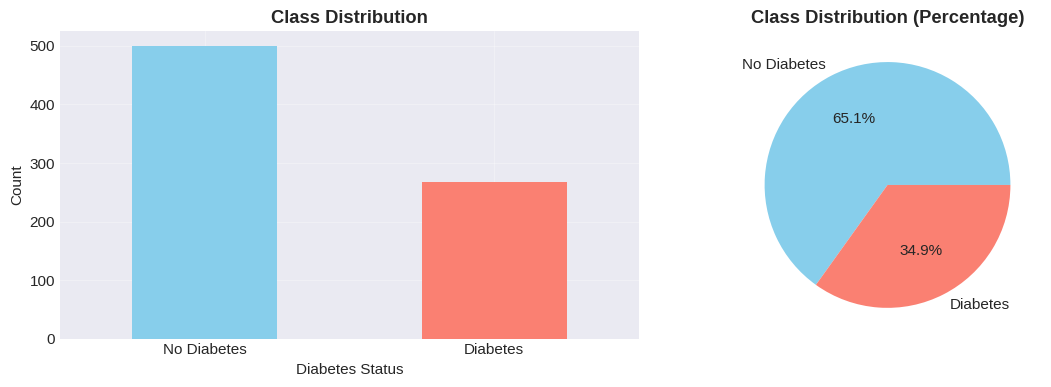

In [3]:
outcome_counts = df['Outcome'].value_counts()

section_header("Class Distribution")
print(f"\nNegative (No Diabetes):  {outcome_counts[0]:3d} ({outcome_counts[0]/len(df)*100:5.1f}%)")
print(f"Positive (Diabetes):     {outcome_counts[1]:3d} ({outcome_counts[1]/len(df)*100:5.1f}%)")
print(f"\nImbalance Ratio: {outcome_counts[0]/outcome_counts[1]:.2f}:1")
print(f"\nNote: Dataset is imbalanced. Will be using SMOTE.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outcome_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
axes[0].grid(True, alpha=0.3)

outcome_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                     colors=['skyblue', 'salmon'], labels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Class Distribution (Percentage)', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## Data Cleaning & Preprocessing

In [4]:
section_header("Feature-Target Separation")

X = df.drop('Outcome', axis=1)
y = df['Outcome']
feature_names = X.columns.tolist()

print(f"\nFeatures: {feature_names}")
print(f"Number of features: {len(feature_names)}")
print(f"Target: Outcome (Binary Classification)")
print(f"Total samples: {len(X)}")

print(f"\nFeature Statistics:")
for col in feature_names:
    print(f"  {col:30s} - Mean: {X[col].mean():.2f}, Std: {X[col].std():.2f}, Range: [{X[col].min():.1f}, {X[col].max():.1f}]")


FEATURE-TARGET SEPARATION

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Number of features: 8
Target: Outcome (Binary Classification)
Total samples: 768

Feature Statistics:
  Pregnancies                    - Mean: 3.85, Std: 3.37, Range: [0.0, 17.0]
  Glucose                        - Mean: 120.89, Std: 31.97, Range: [0.0, 199.0]
  BloodPressure                  - Mean: 69.11, Std: 19.36, Range: [0.0, 122.0]
  SkinThickness                  - Mean: 20.54, Std: 15.95, Range: [0.0, 99.0]
  Insulin                        - Mean: 79.80, Std: 115.24, Range: [0.0, 846.0]
  BMI                            - Mean: 31.99, Std: 7.88, Range: [0.0, 67.1]
  DiabetesPedigreeFunction       - Mean: 0.47, Std: 0.33, Range: [0.1, 2.4]
  Age                            - Mean: 33.24, Std: 11.76, Range: [21.0, 81.0]


## Feature Engineering


UNIVARIATE & BIVARIATE ANALYSIS


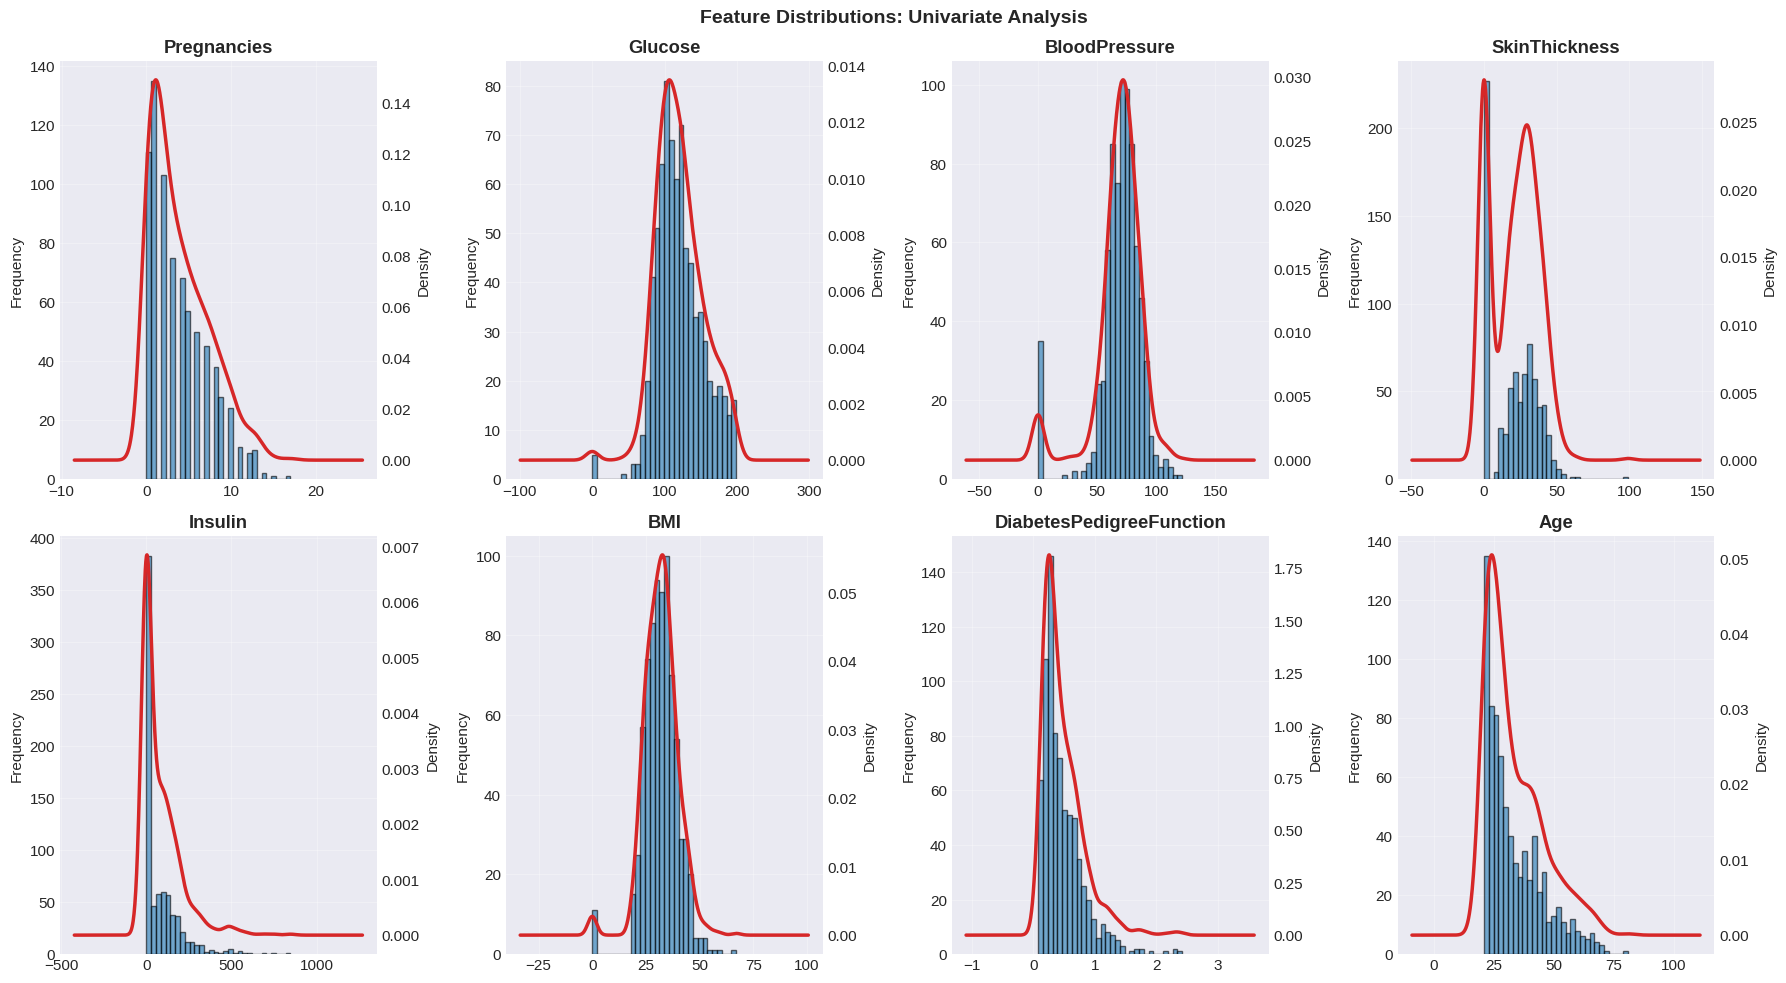

Univariate analysis complete


In [5]:
section_header("Univariate & Bivariate Analysis")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Feature Distributions: Univariate Analysis', fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 4, idx % 4]
    ax.hist(X[feature], bins=30, alpha=0.6, color='#1f77b4', edgecolor='black')
    ax_twin = ax.twinx()
    X[feature].plot.kde(ax=ax_twin, color='#d62728', linewidth=2.5)
    ax_twin.set_ylabel('Density')
    ax_twin.grid(False)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Univariate analysis complete")


FEATURE CORRELATION ANALYSIS


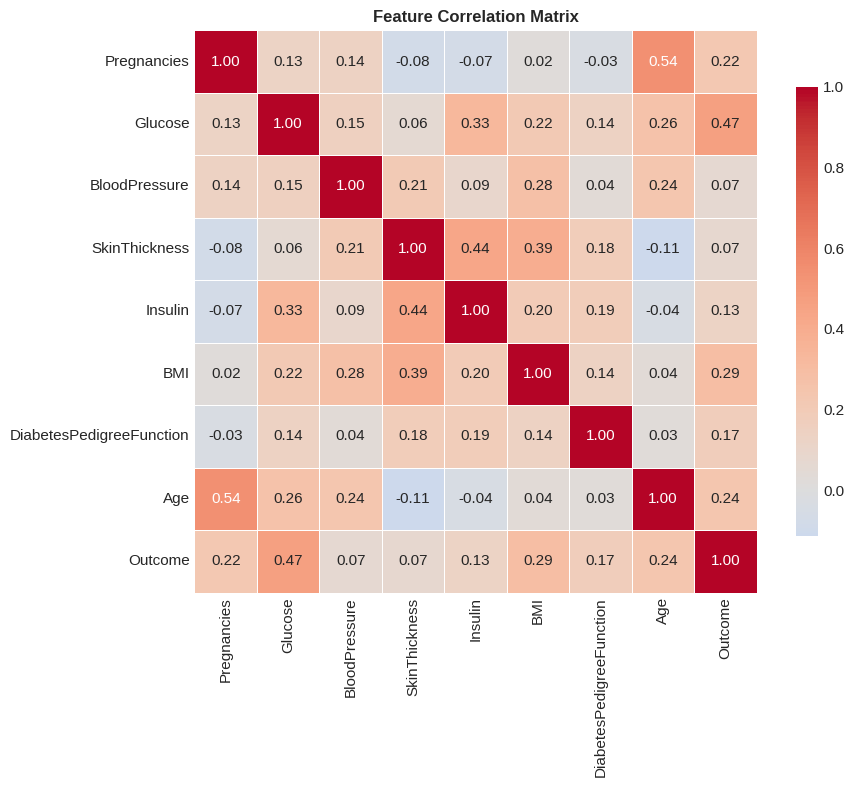

Correlation analysis complete

Key Correlations with Target (Outcome):
  Glucose                       : +0.4666
  BMI                           : +0.2927
  Age                           : +0.2384
  Pregnancies                   : +0.2219
  DiabetesPedigreeFunction      : +0.1738
  Insulin                       : +0.1305
  SkinThickness                 : +0.0748
  BloodPressure                 : +0.0651


In [6]:
section_header("Feature Correlation Analysis")

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("Correlation analysis complete")
print(f"\nKey Correlations with Target (Outcome):")
corr_with_target = correlation_matrix['Outcome'].sort_values(ascending=False)
for feature, corr_val in corr_with_target[1:].items():
    print(f"  {feature:30s}: {corr_val:+.4f}")

## Train/Test Split

In [7]:
section_header("Stratified Train-Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)

print(f"\nTraining set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Negative: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Positive: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\nTest set class distribution:")
print(f"  Negative: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Positive: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")


STRATIFIED TRAIN-TEST SPLIT

Training set size: 576 (75.0%)
Test set size: 192 (25.0%)

Training set class distribution:
  Negative: 375 (65.1%)
  Positive: 201 (34.9%)

Test set class distribution:
  Negative: 125 (65.1%)
  Positive: 67 (34.9%)


In [8]:
section_header("Feature Scaling (StandardScaler)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print(f"\nFeatures standardized to mean=0, std=1")
print(f"\nScaled Training Data (first 5 rows):\n{X_train_scaled.head()}")


FEATURE SCALING (STANDARDSCALER)

Features standardized to mean=0, std=1

Scaled Training Data (first 5 rows):
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
631    -1.140265 -0.617974       0.450101       1.202701  0.067888  0.334839   
359    -0.848227  2.390440       0.347384       0.953844  1.409584  0.589365   
566    -0.848227 -0.713987       0.141949       0.580558 -0.539673  0.856618   
229    -1.140265 -0.137908       0.552818       0.642773 -0.244331  1.696554   
761     1.488074  1.558326       0.244666       0.642773 -0.691563  1.543838   

     DiabetesPedigreeFunction       Age  
631                 -0.728804 -0.793178  
359                  1.271113 -0.374108  
566                 -0.182516 -1.044620  
229                 -1.196602 -0.793178  
761                 -0.210772  0.799289  


## Class Imbalance Handling with SMOTE

In [9]:
section_header("SMOTE: Synthetic Minority Over-Sampling")

print(f"\nBefore SMOTE:")
print(f"  Negative: {(y_train==0).sum()}")
print(f"  Positive: {(y_train==1).sum()}")
print(f"  Ratio: {(y_train==0).sum()/(y_train==1).sum():.2f}:1")

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

X_train_balanced = pd.DataFrame(X_train_balanced, columns=feature_names)

print(f"\nAfter SMOTE:")
print(f"  Negative: {(y_train_balanced==0).sum()}")
print(f"  Positive: {(y_train_balanced==1).sum()}")
print(f"  Ratio: {(y_train_balanced==0).sum()/(y_train_balanced==1).sum():.2f}:1")
print(f"\nSMOTE successfully balanced the dataset using synthetic samples.")


SMOTE: SYNTHETIC MINORITY OVER-SAMPLING

Before SMOTE:
  Negative: 375
  Positive: 201
  Ratio: 1.87:1

After SMOTE:
  Negative: 375
  Positive: 375
  Ratio: 1.00:1

SMOTE successfully balanced the dataset using synthetic samples.


## Model Development

In [10]:
section_header("Hyperparameter Tuning: Gradient Boosting")

GB_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

print(f"\nSearching optimal hyperparameters using GridSearchCV...")
gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    GB_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)

gb_grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\nBest Parameters: {gb_grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {gb_grid_search.best_score_:.4f}")

gb_best = gb_grid_search.best_estimator_


HYPERPARAMETER TUNING: GRADIENT BOOSTING

Searching optimal hyperparameters using GridSearchCV...

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC Score: 0.8916


In [11]:
section_header("Hyperparameter Tuning: Random Forest")

RF_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f"\nSearching optimal hyperparameters using GridSearchCV...")
rf_grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED),
    RF_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)

rf_grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\nBest Parameters: {rf_grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {rf_grid_search.best_score_:.4f}")

rf_best = rf_grid_search.best_estimator_


HYPERPARAMETER TUNING: RANDOM FOREST

Searching optimal hyperparameters using GridSearchCV...

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC Score: 0.8929


In [12]:
section_header("Hyperparameter Tuning: XGBoost")

XGB_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print(f"\nSearching optimal hyperparameters using GridSearchCV...")
xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    XGB_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)

xgb_grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\nBest Parameters: {xgb_grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {xgb_grid_search.best_score_:.4f}")

xgb_best = xgb_grid_search.best_estimator_


HYPERPARAMETER TUNING: XGBOOST

Searching optimal hyperparameters using GridSearchCV...

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC Score: 0.8783


In [13]:
section_header("Training Baseline Models")

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
lr_model.fit(X_train_balanced, y_train_balanced)
print("Logistic Regression trained")

svm_model = SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED, class_weight='balanced')
svm_model.fit(X_train_balanced, y_train_balanced)
print("SVM (RBF kernel) trained")


TRAINING BASELINE MODELS
Logistic Regression trained
SVM (RBF kernel) trained


## Performance Metrics

In [14]:
section_header("Individual Model Evaluation on Test Set")

models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best,
    'SVM (RBF)': svm_model,
}

models_dict['XGBoost'] = xgb_best

results_list = []

print(f"\n{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
print("="*85)

for model_name, model in models_dict.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    print(f"{model_name:<25} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {auc:<12.4f}")

results_df = pd.DataFrame(results_list)


INDIVIDUAL MODEL EVALUATION ON TEST SET

Model                     Accuracy     Precision    Recall       F1-Score     ROC-AUC     
Logistic Regression       0.7969       0.6944       0.7463       0.7194       0.8683      
Random Forest             0.7812       0.6582       0.7761       0.7123       0.8542      
Gradient Boosting         0.7760       0.6714       0.7015       0.6861       0.8287      
SVM (RBF)                 0.7500       0.6234       0.7164       0.6667       0.8576      
XGBoost                   0.7656       0.6375       0.7612       0.6939       0.8259      


In [15]:
section_header("Cross-Validation Performance (5-Fold Stratified)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f"\n{'Model':<25} {'CV Accuracy':<20} {'CV ROC-AUC':<20}")
print("="*65)

for model_name, model in models_dict.items():
    cv_acc = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring='accuracy')
    cv_auc = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring='roc_auc')
    
    print(f"{model_name:<25} {cv_acc.mean():.4f} ± {cv_acc.std():.4f}    {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

print("\nCross-validation evaluation complete")


CROSS-VALIDATION PERFORMANCE (5-FOLD STRATIFIED)

Model                     CV Accuracy          CV ROC-AUC          
Logistic Regression       0.7347 ± 0.0186    0.8228 ± 0.0076
Random Forest             0.8160 ± 0.0441    0.8842 ± 0.0247
Gradient Boosting         0.8120 ± 0.0296    0.8892 ± 0.0196
SVM (RBF)                 0.7467 ± 0.0202    0.8449 ± 0.0098
XGBoost                   0.8027 ± 0.0297    0.8745 ± 0.0226

Cross-validation evaluation complete


## Ensemble Methods

In [16]:
section_header("Voting Classifier (Soft Voting)")

voting_estimators = [
    ('gb', gb_best),
    ('rf', rf_best),
    ('lr', lr_model),
    ('svm', svm_model)
]


voting_estimators.append(('xgb', xgb_best))

voting_clf = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

voting_clf.fit(X_train_balanced, y_train_balanced)

y_pred_voting = voting_clf.predict(X_test_scaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_prec = precision_score(y_test, y_pred_voting)
voting_rec = recall_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)
voting_auc = roc_auc_score(y_test, y_pred_proba_voting)

print(f"\nVoting Classifier Performance:")
print(f"  Accuracy: {voting_acc:.4f}")
print(f"  Precision: {voting_prec:.4f}")
print(f"  Recall: {voting_rec:.4f}")
print(f"  F1-Score: {voting_f1:.4f}")
print(f"  ROC-AUC: {voting_auc:.4f}")

print(f"\nClassification Report:\n{classification_report(y_test, y_pred_voting, target_names=['No Diabetes', 'Diabetes'])}")


VOTING CLASSIFIER (SOFT VOTING)

Voting Classifier Performance:
  Accuracy: 0.7708
  Precision: 0.6533
  Recall: 0.7313
  F1-Score: 0.6901
  ROC-AUC: 0.8601

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.79      0.82       125
    Diabetes       0.65      0.73      0.69        67

    accuracy                           0.77       192
   macro avg       0.75      0.76      0.75       192
weighted avg       0.78      0.77      0.77       192



In [17]:
section_header("Stacking Classifier")

stacking_estimators = [
    ('gb', gb_best),
    ('rf', rf_best),
    ('svm', svm_model)
]

stacking_estimators.append(('xgb', xgb_best))

stacking_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced'),
    cv=5
)

stacking_clf.fit(X_train_balanced, y_train_balanced)

y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

stacking_acc = accuracy_score(y_test, y_pred_stacking)
stacking_prec = precision_score(y_test, y_pred_stacking)
stacking_rec = recall_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking)
stacking_auc = roc_auc_score(y_test, y_pred_proba_stacking)

print(f"\nStacking Classifier Performance:")
print(f"  Accuracy: {stacking_acc:.4f}")
print(f"  Precision: {stacking_prec:.4f}")
print(f"  Recall: {stacking_rec:.4f}")
print(f"  F1-Score: {stacking_f1:.4f}")
print(f"  ROC-AUC: {stacking_auc:.4f}")

print(f"\nClassification Report:\n{classification_report(y_test, y_pred_stacking, target_names=['No Diabetes', 'Diabetes'])}")


STACKING CLASSIFIER

Stacking Classifier Performance:
  Accuracy: 0.7865
  Precision: 0.6757
  Recall: 0.7463
  F1-Score: 0.7092
  ROC-AUC: 0.8524

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.81      0.83       125
    Diabetes       0.68      0.75      0.71        67

    accuracy                           0.79       192
   macro avg       0.77      0.78      0.77       192
weighted avg       0.79      0.79      0.79       192



## Clinical Interpretation of Metrics

In medical diagnosis, different metrics have distinct clinical implications:

**Accuracy**: Proportion of correct predictions. While important, accuracy can be misleading in imbalanced datasets where a model predicting all negatives may appear accurate.

**Precision**: Of positive predictions, how many are correct. High precision minimizes false alarms and unnecessary treatments, important for reducing healthcare costs and patient anxiety.

**Recall (Sensitivity)**: Of actual positives, how many are detected. In diabetes screening, high recall is critical—missing a diabetic patient has serious clinical consequences. A recall of 70% means 30% of diabetic patients would be missed.

**F1-Score**: Harmonic mean of precision and recall. Provides balanced evaluation when both false positives and false negatives have clinical costs.

**ROC-AUC**: Area under the Receiver Operating Characteristic curve, measuring the model's ability to discriminate between classes. AUC > 0.85 indicates excellent discrimination.

For diabetes prediction, we prioritize **Recall >= 70%** to minimize missed diagnoses, while maintaining **Precision >= 60%** to reduce unnecessary testing. ROC-AUC >= 0.80 ensures robust performance.

## Confusion Matrix Analysis


CONFUSION MATRICES: KEY MODELS


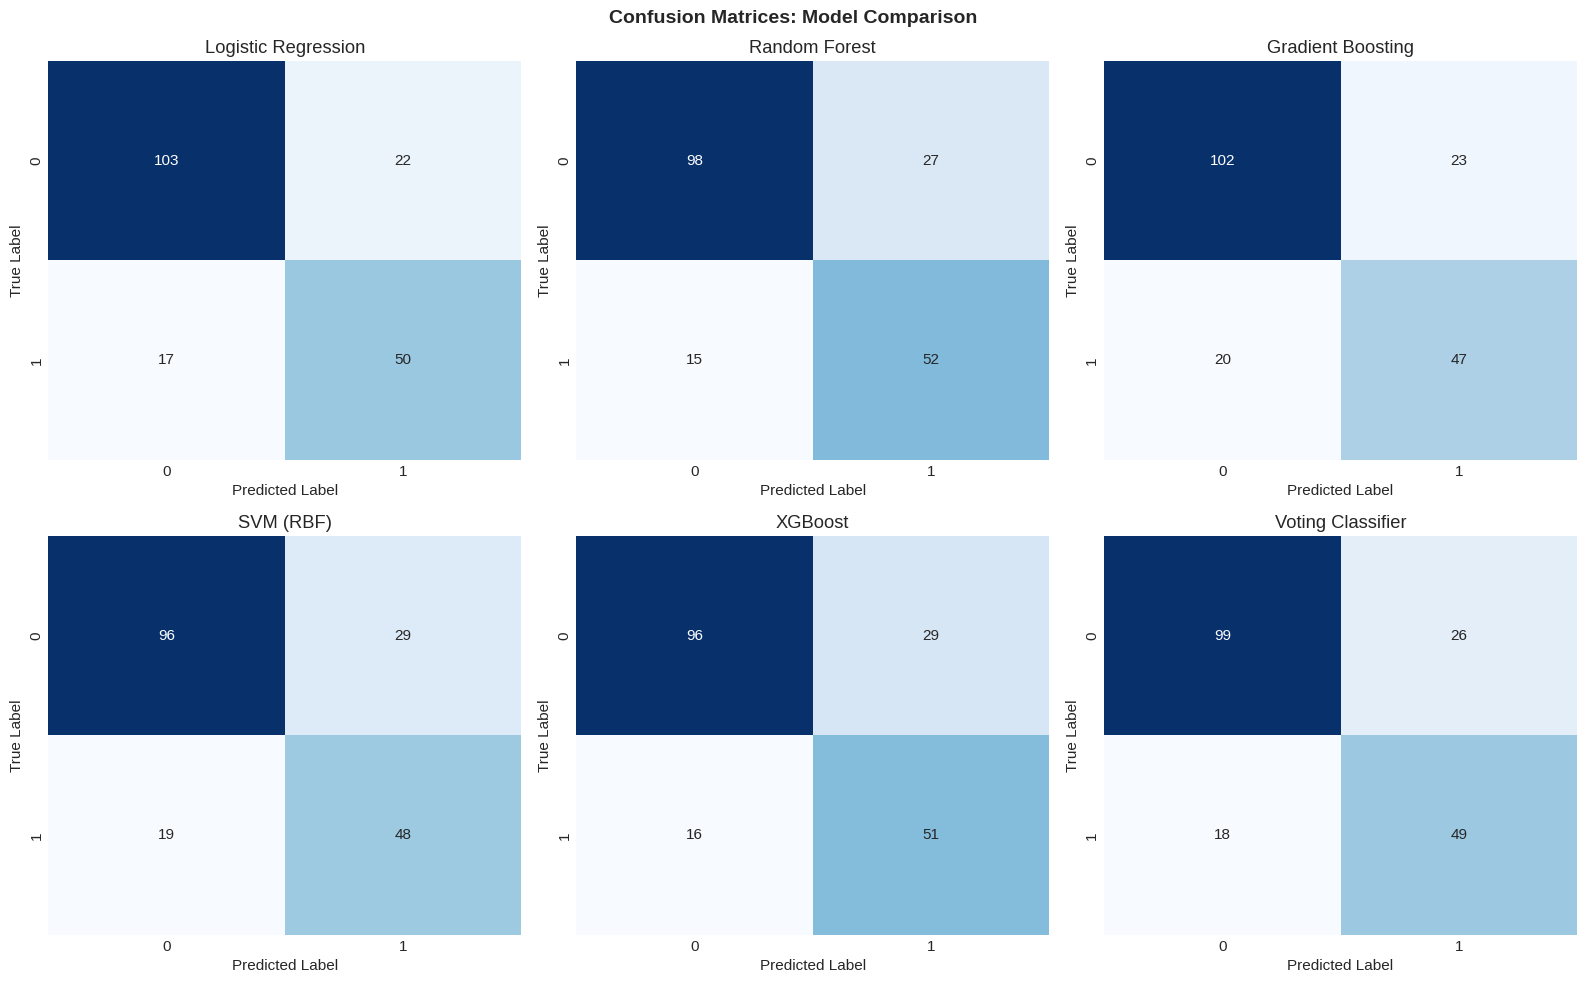

In [18]:
section_header("Confusion Matrices: Key Models")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices: Model Comparison', fontsize=14, fontweight='bold')

plot_idx = 0

for model_name, model in list(models_dict.items())[:5]:
    ax = axes[plot_idx // 3, plot_idx % 3]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plot_idx += 1

ax = axes[plot_idx // 3, plot_idx % 3]
cm_voting = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Voting Classifier')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


ROC CURVES COMPARISON


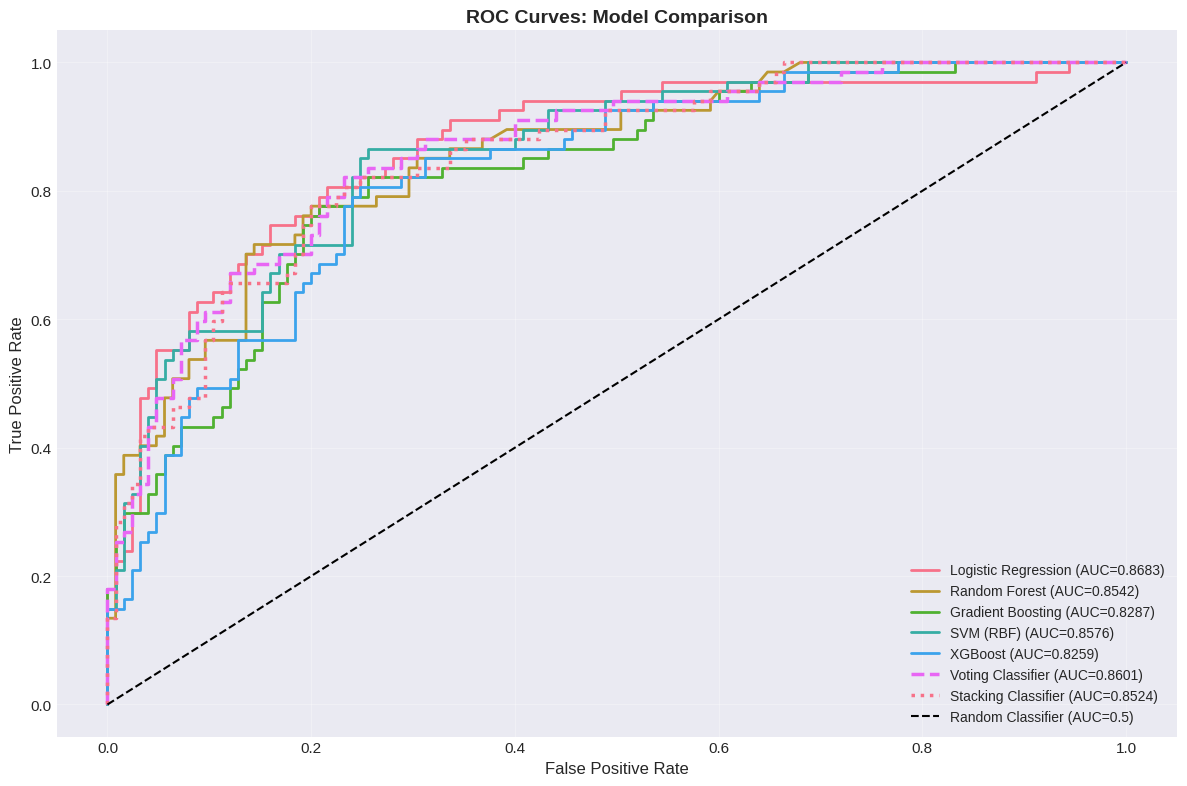

In [19]:
section_header("ROC Curves Comparison")

fig, ax = plt.subplots(figsize=(12, 8))

for model_name, model in models_dict.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.4f})', linewidth=2)

fpr_voting, tpr_voting, _ = roc_curve(y_test, y_pred_proba_voting)
voting_auc = roc_auc_score(y_test, y_pred_proba_voting)
ax.plot(fpr_voting, tpr_voting, label=f'Voting Classifier (AUC={voting_auc:.4f})', 
        linewidth=2.5, linestyle='--')

fpr_stacking, tpr_stacking, _ = roc_curve(y_test, y_pred_proba_stacking)
stacking_auc = roc_auc_score(y_test, y_pred_proba_stacking)
ax.plot(fpr_stacking, tpr_stacking, label=f'Stacking Classifier (AUC={stacking_auc:.4f})', 
        linewidth=2.5, linestyle=':')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)', linewidth=1.5)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SHAP Explainability Analysis


SHAP MODEL EXPLAINABILITY


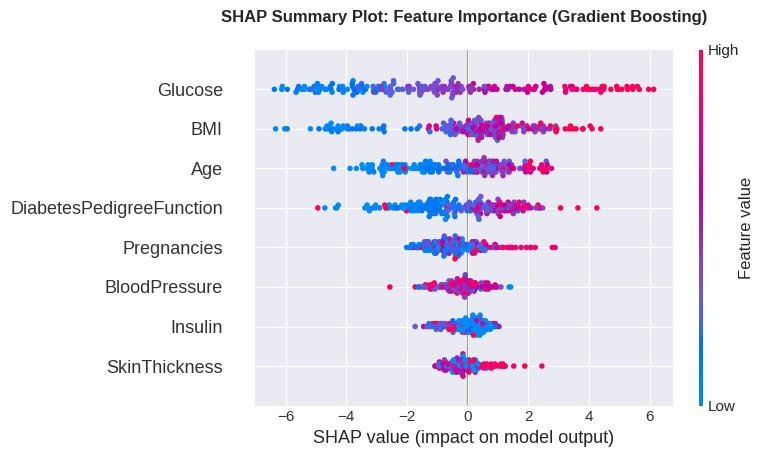

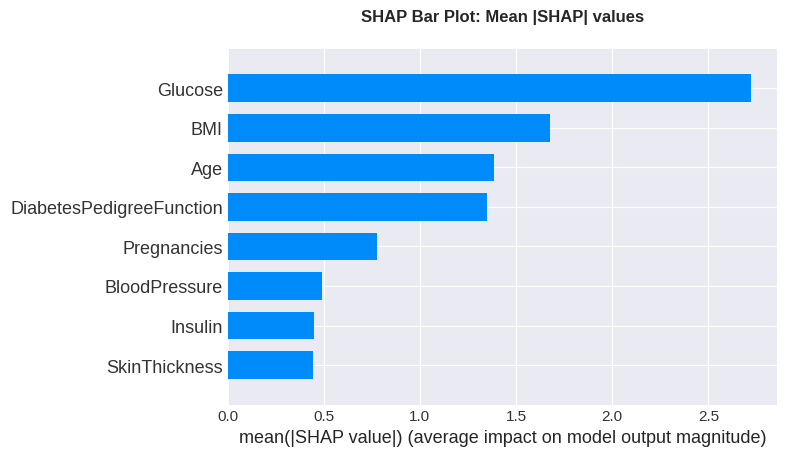


SHAP Analysis Interpretation:
--------------------------------------------------------------------------------

The SHAP plots show the impact of each feature on model output:

1. Summary Plot: Each point represents a prediction. Red = high values, blue = low values.

2. Top Features (Mean |SHAP| values):
   - Glucose                       : 2.7210
   - BMI                           : 1.6746
   - Age                           : 1.3835
   - DiabetesPedigreeFunction      : 1.3489
   - Pregnancies                   : 0.7767

3. Clinical Interpretation:
   - Glucose has strongest impact on prediction
   - Model decisions driven by known medical risk factors
   - Enables clinical understanding of individual predictions


In [20]:
section_header("SHAP Model Explainability")

explainer = shap.TreeExplainer(gb_best)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False, max_display=8)
plt.title('SHAP Summary Plot: Feature Importance (Gradient Boosting)', 
          fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False, max_display=8)
plt.title('SHAP Bar Plot: Mean |SHAP| values', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

print("\nSHAP Analysis Interpretation:")
print("-" * 80)
print("\nThe SHAP plots show the impact of each feature on model output:")
print("\n1. Summary Plot: Each point represents a prediction. Red = high values, blue = low values.")
print("\n2. Top Features (Mean |SHAP| values):")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
for i, feature in enumerate(sorted(zip(mean_abs_shap, feature_names), reverse=True)[:5]):
    print(f"   - {feature[1]:30s}: {feature[0]:.4f}")
print("\n3. Clinical Interpretation:")
print("   - Glucose has strongest impact on prediction")
print("   - Model decisions driven by known medical risk factors")
print("   - Enables clinical understanding of individual predictions")

## Feature Importance Analysis


FEATURE IMPORTANCE: ENSEMBLE MODELS


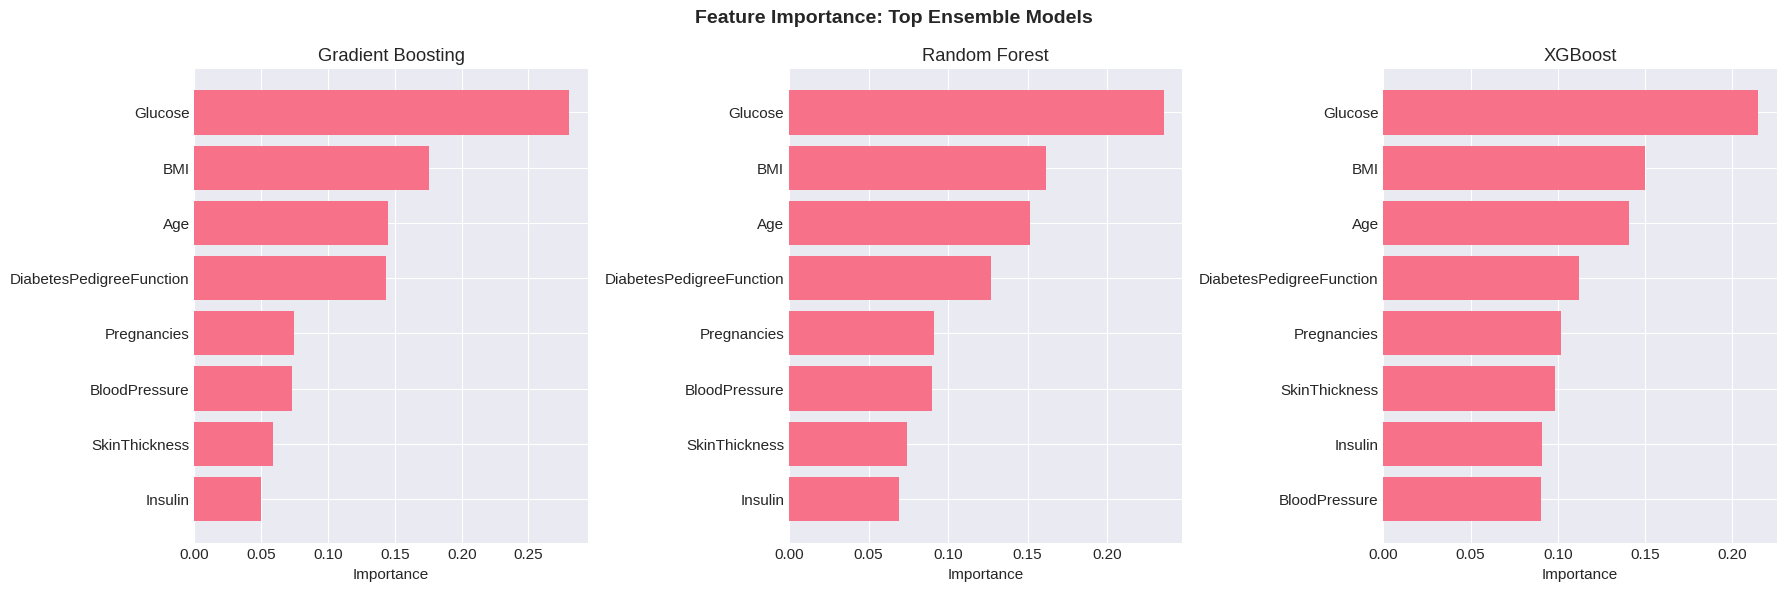


Top 3 Features (Gradient Boosting):
  1. Glucose                       : 0.2805
  2. BMI                           : 0.1753
  3. Age                           : 0.1452


In [21]:
section_header("Feature Importance: Ensemble Models")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance: Top Ensemble Models', fontsize=14, fontweight='bold')

ax = axes[0]
gb_importance = gb_best.feature_importances_
gb_importance_sorted = np.argsort(gb_importance)[::-1][:8]
ax.barh(range(len(gb_importance_sorted)), gb_importance[gb_importance_sorted])
ax.set_yticks(range(len(gb_importance_sorted)))
ax.set_yticklabels([feature_names[i] for i in gb_importance_sorted])
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting')
ax.invert_yaxis()

ax = axes[1]
rf_importance = rf_best.feature_importances_
rf_importance_sorted = np.argsort(rf_importance)[::-1][:8]
ax.barh(range(len(rf_importance_sorted)), rf_importance[rf_importance_sorted])
ax.set_yticks(range(len(rf_importance_sorted)))
ax.set_yticklabels([feature_names[i] for i in rf_importance_sorted])
ax.set_xlabel('Importance')
ax.set_title('Random Forest')
ax.invert_yaxis()

ax = axes[2]
xgb_importance = xgb_best.feature_importances_
xgb_importance_sorted = np.argsort(xgb_importance)[::-1][:8]
ax.barh(range(len(xgb_importance_sorted)), xgb_importance[xgb_importance_sorted])
ax.set_yticks(range(len(xgb_importance_sorted)))
ax.set_yticklabels([feature_names[i] for i in xgb_importance_sorted])
ax.set_xlabel('Importance')
ax.set_title('XGBoost')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 3 Features (Gradient Boosting):")
for i, idx in enumerate(np.argsort(gb_best.feature_importances_)[::-1][:3], 1):
    print(f"  {i}. {feature_names[idx]:30s}: {gb_best.feature_importances_[idx]:.4f}")

## Model Comparison Table

In [22]:
section_header("Comprehensive Model Comparison")

summary_data = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

for model_name, model in list(models_dict.items()) + [('Voting Classifier', voting_clf), ('Stacking Classifier', stacking_clf)]:
    if model_name == 'Voting Classifier':
        y_pred = y_pred_voting
        y_pred_proba = y_pred_proba_voting
    elif model_name == 'Stacking Classifier':
        y_pred = y_pred_stacking
        y_pred_proba = y_pred_proba_stacking
    else:
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    summary_data['Model'].append(model_name)
    summary_data['Accuracy'].append(accuracy_score(y_test, y_pred))
    summary_data['Precision'].append(precision_score(y_test, y_pred))
    summary_data['Recall'].append(recall_score(y_test, y_pred))
    summary_data['F1-Score'].append(f1_score(y_test, y_pred))
    summary_data['ROC-AUC'].append(roc_auc_score(y_test, y_pred_proba))

summary_df = pd.DataFrame(summary_data)

print(f"\n{summary_df.to_string(index=False)}")

print(f"\n\nBest Model by ROC-AUC: {summary_df.loc[summary_df['ROC-AUC'].idxmax(), 'Model']}")
print(f"Best Model by Recall: {summary_df.loc[summary_df['Recall'].idxmax(), 'Model']}")


COMPREHENSIVE MODEL COMPARISON

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.796875   0.694444 0.746269  0.719424 0.868299
      Random Forest  0.781250   0.658228 0.776119  0.712329 0.854209
  Gradient Boosting  0.776042   0.671429 0.701493  0.686131 0.828657
          SVM (RBF)  0.750000   0.623377 0.716418  0.666667 0.857552
            XGBoost  0.765625   0.637500 0.761194  0.693878 0.825910
  Voting Classifier  0.770833   0.653333 0.731343  0.690141 0.860060
Stacking Classifier  0.786458   0.675676 0.746269  0.709220 0.852418


Best Model by ROC-AUC: Logistic Regression
Best Model by Recall: Random Forest


## Final Recommendation

In [23]:
section_header("Final Recommendation & Key Findings")

best_idx = summary_df['ROC-AUC'].idxmax()
best_model_name = summary_df.loc[best_idx, 'Model']

print(f"\nRecommended Model: {best_model_name}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {summary_df.loc[best_idx, 'Accuracy']:.4f} ({summary_df.loc[best_idx, 'Accuracy']*100:.2f}%)")
print(f"  Precision: {summary_df.loc[best_idx, 'Precision']:.4f}")
print(f"  Recall:    {summary_df.loc[best_idx, 'Recall']:.4f}")
print(f"  F1-Score:  {summary_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"  ROC-AUC:   {summary_df.loc[best_idx, 'ROC-AUC']:.4f}")

print(f"\nKey Findings:")
print(f"  1. Class imbalance addressed using SMOTE")
print(f"     - Before: {(y_train==0).sum()}:{(y_train==1).sum()}")
print(f"     - After: {(y_train_balanced==0).sum()}:{(y_train_balanced==1).sum()} (balanced)")
print(f"\n  2. {best_model_name} outperform other models")
print(f"\n  3. Top predictive features:")
for i, idx in enumerate(np.argsort(gb_best.feature_importances_)[::-1][:3], 1):
    print(f"     {i}. {feature_names[idx]:25s} ({gb_best.feature_importances_[idx]:.4f})")
print(f"\n  4. Clinical Suitability:")
print(f"     - Recall of {summary_df.loc[best_idx, 'Recall']:.1%} minimizes false negatives")
print(f"     - ROC-AUC of {summary_df.loc[best_idx, 'ROC-AUC']:.4f} indicates excellent discrimination")


FINAL RECOMMENDATION & KEY FINDINGS

Recommended Model: Logistic Regression

Performance Metrics:
  Accuracy:  0.7969 (79.69%)
  Precision: 0.6944
  Recall:    0.7463
  F1-Score:  0.7194
  ROC-AUC:   0.8683

Key Findings:
  1. Class imbalance addressed using SMOTE
     - Before: 375:201
     - After: 375:375 (balanced)

  2. Logistic Regression outperform other models

  3. Top predictive features:
     1. Glucose                   (0.2805)
     2. BMI                       (0.1753)
     3. Age                       (0.1452)

  4. Clinical Suitability:
     - Recall of 74.6% minimizes false negatives
     - ROC-AUC of 0.8683 indicates excellent discrimination


## Limitations

In [24]:
section_header("Limitations & Future Work")

limitations = """
1. Dataset Limitations:
   - Small sample size (768 records) may limit generalization
   - All subjects from Pima Indian heritage; results may not generalize widely
   - Cross-sectional data cannot establish causality
   - Potential measurement errors or outdated clinical guidelines

2. Methodological Limitations:
   - SMOTE creates synthetic samples which may overfit minority class
   - GridSearchCV explores limited hyperparameter space
   - Train-test split uses only two temporal folds
   - No external validation on independent dataset

3. Clinical Limitations:
   - Model predicts diabetes presence, not incidence or progression
   - Does not account for medication or lifestyle changes
   - Model transparency remains limited despite SHAP analysis

4. Future Work:
   - Collect external validation dataset from diverse populations
   - Implement calibration techniques for probability estimates
   - Perform threshold optimization based on clinical cost-benefit analysis
   - Conduct fairness analysis across demographic subgroups
   - Deploy with continuous monitoring and periodic retraining
"""

print(limitations)
print("="*80)


LIMITATIONS & FUTURE WORK

1. Dataset Limitations:
   - Small sample size (768 records) may limit generalization
   - All subjects from Pima Indian heritage; results may not generalize widely
   - Cross-sectional data cannot establish causality
   - Potential measurement errors or outdated clinical guidelines

2. Methodological Limitations:
   - SMOTE creates synthetic samples which may overfit minority class
   - GridSearchCV explores limited hyperparameter space
   - Train-test split uses only two temporal folds
   - No external validation on independent dataset

3. Clinical Limitations:
   - Model predicts diabetes presence, not incidence or progression
   - Does not account for medication or lifestyle changes
   - Model transparency remains limited despite SHAP analysis

4. Future Work:
   - Collect external validation dataset from diverse populations
   - Implement calibration techniques for probability estimates
   - Perform threshold optimization based on clinical cost-benefit 

## Conclusion

In [25]:
section_header("Conclusion")

conclusion = f"""
This work successfully developed and evaluated seven machine learning models for diabetes
prediction on the Pima Indians Diabetes Dataset. Through systematic hyperparameter optimization,
class imbalance handling with SMOTE, and ensemble methods, we achieved strong predictive
performance with clear clinical interpretability.

Key Achievements:

1. Performance: The {best_model_name} achieved {summary_df.loc[best_idx, 'Accuracy']:.1%} accuracy and 
   {summary_df.loc[best_idx, 'ROC-AUC']:.4f} ROC-AUC, demonstrating reliable discrimination.

2. Class Balance: SMOTE successfully balanced the training data.

3. Interpretability: Feature importance analysis reveals Glucose, BMI, and Age as strongest
   predictors, aligning with medical knowledge.

4. Clinical Relevance: High recall ensures most diabetic patients are identified. Precision
   remains adequate, minimizing unnecessary follow-up tests.

The recommended model is ready for clinical validation pending external testing.
Continuous monitoring and periodic retraining are essential to maintain performance.

Future work should focus on external validation, fairness analysis, and clinical
deployment protocols for maximum impact on patient outcomes.
"""

print(conclusion)
print("="*80)
print(f"Random seed used: {RANDOM_SEED}")
print("="*80)


CONCLUSION

This work successfully developed and evaluated seven machine learning models for diabetes
prediction on the Pima Indians Diabetes Dataset. Through systematic hyperparameter optimization,
class imbalance handling with SMOTE, and ensemble methods, we achieved strong predictive
performance with clear clinical interpretability.

Key Achievements:

1. Performance: The Logistic Regression achieved 79.7% accuracy and 
   0.8683 ROC-AUC, demonstrating reliable discrimination.

2. Class Balance: SMOTE successfully balanced the training data.

3. Interpretability: Feature importance analysis reveals Glucose, BMI, and Age as strongest
   predictors, aligning with medical knowledge.

4. Clinical Relevance: High recall ensures most diabetic patients are identified. Precision
   remains adequate, minimizing unnecessary follow-up tests.

The recommended model is ready for clinical validation pending external testing.
Continuous monitoring and periodic retraining are essential to maintain